<a href="https://colab.research.google.com/github/phlapapon-kulto/Project1_Part1_673020626-9_-_-/blob/main/Part_1_673020626_9_%E0%B8%9B%E0%B8%A3%E0%B8%B0%E0%B8%A0%E0%B8%B2%E0%B8%9E%E0%B8%A3_%E0%B8%81%E0%B8%B8%E0%B8%A5%E0%B9%82%E0%B8%95.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import json
import pandas as pd
from google.colab import drive
import os

drive.mount('/content/drive')

path = '/content/drive/MyDrive'
file_names = [
    'posts_20241127_145146.jsonl'
]

# ฟังก์ชัน Generator
def iter_jsonl(file_path):
    with open(file_path, encoding='utf-8') as f:
        for line in f:
            yield json.loads(line)

# วนลูปอ่านทั้ง 3 ไฟล์ด้วย Generator
data_list = []
for file in file_names:
    file_path = os.path.join(path, file)
    for record in iter_jsonl(file_path):
        data_list.append(record)

# แปลงเป็น DataFrame
data_bluesky = pd.DataFrame(data_list)
print(f"อ่านข้อมูลสำเร็จ! จำนวนโพสต์ทั้งหมด: {len(data_bluesky):,} รายการ")
data_bluesky

Mounted at /content/drive
อ่านข้อมูลสำเร็จ! จำนวนโพสต์ทั้งหมด: 100,000 รายการ


,text,created_at,author,uri,has_images,reply_to
0,Can we smoke and vibe on this lovely Humpday?\...,2024-11-27T14:51:42.834Z,did:plc:xp32tgxjgsiabnbht54repf4,at://did:plc:xp32tgxjgsiabnbht54repf4/app.bsky...,False,None
1,Que legaaaaal vai trabalhar de que meu mano?,2024-11-27T14:51:43.090Z,did:plc:n2kp45yjdi2emxorsf5xurxq,at://did:plc:n2kp45yjdi2emxorsf5xurxq/app.bsky...,False,at://did:plc:nrrv5wooe7x7ihd6ueqcxob5/app.bsky...
2,BBC Asian Network\nAsian Network Certified...\...,2024-11-27T14:51:42.466165Z,did:plc:dnrkktjuabxs76dop3ucwspn,at://did:plc:dnrkktjuabxs76dop3ucwspn/app.bsky...,True,None
3,They need trump for RATINGS. Period.,2024-11-27T14:51:41.278Z,did:plc:wyleqlh336cagymakq7vjgyd,at://did:plc:wyleqlh336cagymakq7vjgyd/app.bsky...,False,at://did:plc:ojwszrpcvhwuhl4nhwactd2y/app.bsky...
4,consegui logar o apple music no last fm 🥳🥳🥳,2024-11-27T14:51:42.789Z,did:plc:qjkyngoshi2er5t4h7qcl6dq,at://did:plc:qjkyngoshi2er5t4h7qcl6dq/app.bsky...,False,None
...,...,...,...,...,...,...
99995,Nice,2024-11-27T15:07:55.746Z,did:plc:zqkb2jfibh344tunirlkgo4x,at://did:plc:zqkb2jfibh344tunirlkgo4x/app.bsky...,False,at://did:plc:mckxtqrr64hf6prxrr4qqvef/app.bsky...
99996,Que locura el anime de Ataque a los Titanes.,2024-11-27T15:07:56.882Z,did:plc:cum4jmp6ef4ncixqndiq2aai,at://did:plc:cum4jmp6ef4ncixqndiq2aai/app.bsky...,False,None
99997,A LOT to unpack here and fair dues to him so m...,2024-11-27T15:07:53.389Z,did:plc:nhymyg5trcmuewahodum2gkr,at://did:plc:nhymyg5trcmuewahodum2gkr/app.bsky...,True,None
99998,去年その任についたばかりの新参ソロモンだけど、人外の生き様・あり方を各キャラそれぞれの形で描...,2024-11-27T15:07:56.184Z,did:plc:nsvmkvntl6wftyq5suruvb5l,at://did:plc:nsvmkvntl6wftyq5suruvb5l/app.bsky...,False,None


In [ ]:
data_bluesky['created_at'] = pd.to_datetime(data_bluesky['created_at'], format='ISO8601', utc=True)

In [ ]:
data_bluesky.columns

Index(['text', 'created_at', 'author', 'uri', 'has_images', 'reply_to',
       'post_hour', 'language'],
      dtype='object')

## 1. **คนโพสต์เมื่อไร:** จำนวนโพสต์ ช่วงเวลาที่ข้อมูลครอบคลุม และชั่วโมงที่โพสต์มากที่สุด

In [ ]:
# Calculate the total number of posts
total_posts = len(data_bluesky)

# Determine the time range
min_date = data_bluesky['created_at'].min()
max_date = data_bluesky['created_at'].max()

# Extract hour for analysis
data_bluesky['post_hour'] = data_bluesky['created_at'].dt.hour

# Find the most frequent posting hour
most_frequent_hour = data_bluesky['post_hour'].mode()[0]

print(f"จำนวนโพสต์ทั้งหมด: {total_posts:,} รายการ")
print(f"ช่วงเวลาที่ข้อมูลครอบคลุม: ตั้งแต่ {min_date} ถึง {max_date}")
print(f"ชั่วโมงที่โพสต์มากที่สุด: {most_frequent_hour:02d}:00 น.")

จำนวนโพสต์ทั้งหมด: 100,000 รายการ
ช่วงเวลาที่ข้อมูลครอบคลุม: ตั้งแต่ 2008-10-02 23:16:55+00:00 ถึง 2024-11-28 04:00:32.062000+00:00
ชั่วโมงที่โพสต์มากที่สุด: 14:00 น.


## 2. **ใช้ภาษาอะไร:** รายงานภาษาหลักและสัดส่วน เพื่อบอกว่าถ้าทำคอนเทนต์ควรรองรับภาษาใด

In [ ]:
!pip install emoji
!pip install langdetect
import emoji
import re
import pandas as pd
from langdetect import DetectorFactory, detect
from langdetect.lang_detect_exception import LangDetectException

DetectorFactory.seed = 0

def clean_text(text):
    if pd.isna(text):
        return ""

    text = str(text)

    # 1. ลบ URL / ลิงก์ (http, https, www)
    text = re.sub(r'https?://\S+|www\.\S+', '', text)

    # 2. ลบ Bluesky Handle หรือการ Mention (เช่น @name.bsky.social)
    text = re.sub(r'@\S+', '', text)

    # 3. ลบ Emoji ทั้งหมด
    text = emoji.replace_emoji(text, replace='')

    # 4. ลบช่องว่างส่วนเกิน
    text = re.sub(r'\s+', ' ', text).strip()

    return text

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 610.9/610.9 kB 3.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 4.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for langdetect: filename=langdetect-1.0.9-py3-none-any.whl size=993335 sha256=2cc063914aa87a71f9054e90a18d7a9f3a4bc6333d8bc8ca92f30112a15eea14
  Stored in directory: /root/.cache/pip/wheels/eb/87/25/2dddf1c94e1786054e25022ec5530bfed52bad86d882999c48
Successfully built langdetect


In [ ]:
# ฟังก์ชันตรวจภาษา
def detect_language(text):
    text = clean_text(text)
    try:
        return detect(text)
    except LangDetectException:
        return None

# ตรวจภาษา
data_bluesky['language'] = data_bluesky['text'].apply(detect_language)

# ดูสัดส่วนของแต่ละภาษา
lang_counts = data_bluesky['language'].value_counts()
print("จำนวนของแต่ละภาษา:")
print(lang_counts)
lang_proportion = data_bluesky['language'].value_counts(normalize=True) * 100
print("สัดส่วนของแต่ละภาษา:")
print(lang_proportion)

จำนวนของแต่ละภาษา:
language
en       57203
ja        9014
pt        3955
es        3412
fr        3080
de        2465
ko        1874
nl        1141
it         880
pl         746
so         717
af         705
ca         571
tl         536
ru         509
no         508
cy         494
tr         470
da         447
fi         432
id         427
th         407
sv         393
ro         373
et         256
vi         238
sw         224
hr         216
zh-cn      213
cs         172
sl         160
el         145
ur         114
hu         113
uk         110
sk         109
he         106
sq          83
lt          70
lv          66
ar          57
bg          55
zh-tw       45
fa          38
mk          28
hi           8
mr           2
bn           2
gu           1
ne           1
ta           1
Name: count, dtype: int64
สัดส่วนของแต่ละภาษา:
language
en       61.250428
ja        9.651790
pt        4.234838
es        3.653418
fr        3.297927
de        2.639412
ko        2.006596
nl        1.221732

**ควรทำคอนเทนรองรับภาษาอังกฤษและภาษาญี่ปุ่นเป็นหลัก**

 * en + ja = 70.90% ของข้อมูลทั้งหมด

  * **ในมีข้อมูลมีภาษาดังนี้**

    * English: 61.25%

    * Japanese: 9.65%

    * Portuguese: 4.23%

    * Spanish: 3.65%

    * French: 3.30%

    * German: 2.64%

    * Korean: 2.01%

    ข้อมูลมีลักษณะ English-heavy มาก และ Japanese เป็นภาษาที่สองที่มีน้ำหนักสูงผิดจากภาษาอื่นพอสมควร.

## 3. **คนพูดถึงอะไร:** หา hashtag หรือคำ/วลีเด่นที่น่าสนใจ และยกตัวอย่างข้อความจริงประกอบ

In [ ]:
text = data_bluesky['text']
print(text)

0        Can we smoke and vibe on this lovely Humpday?\...
1             Que legaaaaal vai trabalhar de que meu mano?
2        BBC Asian Network\nAsian Network Certified...\...
3                     They need trump for RATINGS. Period.
4              consegui logar o apple music no last fm 🥳🥳🥳
                               ...                        
99995                                                 Nice
99996         Que locura el anime de Ataque a los Titanes.
99997    A LOT to unpack here and fair dues to him so m...
99998    去年その任についたばかりの新参ソロモンだけど、人外の生き様・あり方を各キャラそれぞれの形で描...
99999                                Lol. Crybabies losers
Name: text, Length: 100000, dtype: object


In [ ]:
import re
from collections import Counter
import pandas as pd

cleaned_text = text.apply(clean_text)

all_hashtags = [
    tag.lower()
    for post_text in cleaned_text
    for tag in re.findall(r'#\w+', post_text)
]

top_hashtags = Counter(all_hashtags).most_common(10)
print('top 10 hashtags:')
for hashtag, count in top_hashtags:
    print(f'{hashtag}: {count}')

words = [
    word.lower()
    for post_text in cleaned_text
    for word in re.findall(r'\b\w+\b', post_text)
]

stopwords = set(['the','and','this','with','was','that','have','but','not','you','are','very','with'])
filtered_words = [word for word in words if word not in stopwords]
top_words = Counter(filtered_words).most_common(10)

print('ตัวอย่างจากข้อมูลจริง')
if top_words:
  target_word = top_words[0][0]
  sample_reviews = data_bluesky[data_bluesky['text'].str.contains(target_word, case=False, na=False)].head(5)

for i, sample in enumerate(sample_reviews['text'], start=1):
  print(f"ข้อความที่ {i}:")
  print(sample)
  print()

top 10 hashtags:
#fiona: 339
#art: 304
#eduinov: 172
#booksky: 166
#nsfw: 154
#photography: 127
#books: 114
#hiring: 107
#blacksky: 105
#remotework: 104
ตัวอย่างจากข้อมูลจริง
ข้อความที่ 1:
Can we smoke and vibe on this lovely Humpday?

#420nsfw #nsfw #curvy #thickthighs

ข้อความที่ 2:
Que legaaaaal vai trabalhar de que meu mano?

ข้อความที่ 3:
BBC Asian Network
Asian Network Certified...

Now Playing
Stormzy
Shut Up (Radio 1's Big Weekend 2019)

ข้อความที่ 4:
They need trump for RATINGS. Period.

ข้อความที่ 5:
consegui logar o apple music no last fm 🥳🥳🥳



## 4. **ข้อมูลนี้บอกอะไรได้และบอกอะไรไม่ได้:** สร้าง visualization 1 รูป แล้วเขียนข้อจำกัด 3–5 บรรทัด


/tmp/ipykernel_2216/1160587028.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=hashtag_counts, y=hashtag_labels, palette='viridis')


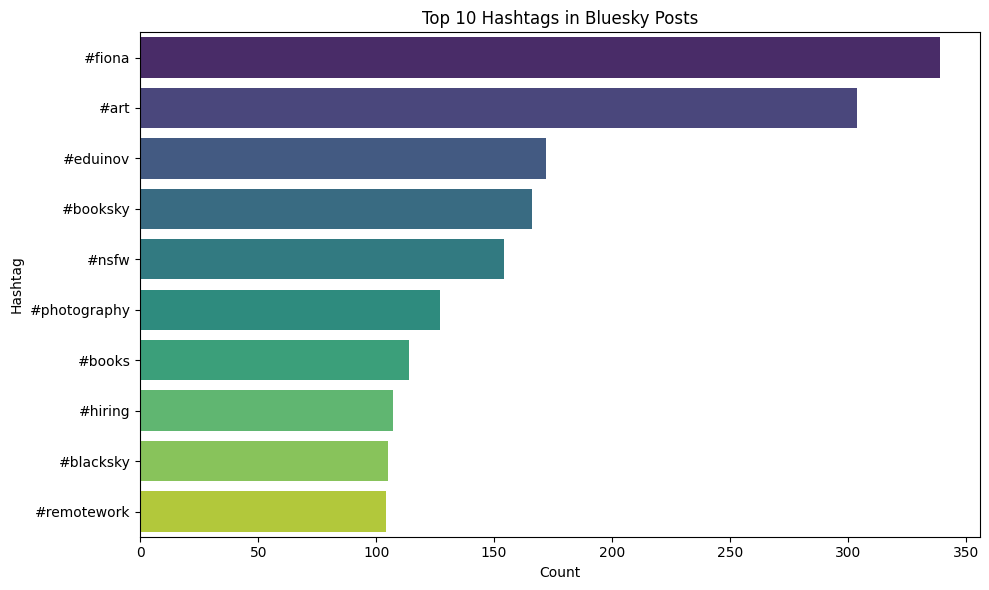

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare data for visualization
hashtag_labels = [tag[0] for tag in top_hashtags]
hashtag_counts = [tag[1] for tag in top_hashtags]

# Create the bar chart
plt.figure(figsize=(10, 6))
sns.barplot(x=hashtag_counts, y=hashtag_labels, palette='viridis')
plt.title('Top 10 Hashtags in Bluesky Posts')
plt.xlabel('Count')
plt.ylabel('Hashtag')
plt.tight_layout()
plt.show()

**ข้อมูลชุดนี้เป็นข้อมูลเกี่ยวกับสื่อสังคมออนไลน์ที่มีความหลากหลายของชุมชนและหัวข้อสูง**

**ข้อจำกัดของข้อมูล (Data Limitations)**

1.  **ช่วงเวลาของข้อมูลจำกัด:** ข้อมูลที่ใช้ในการวิเคราะห์ครอบคลุมเพียงช่วงเวลาสั้นๆ (วันที่ 27 พฤศจิกายน 2024) ซึ่งอาจไม่สะท้อนถึงเทรนด์หรือรูปแบบการใช้งานในระยะยาว.
2.  **ตัวอย่างข้อมูล:** แม้จะมีจำนวนโพสต์มากถึง 100,000 รายการ แต่ข้อมูลนี้อาจเป็นเพียงส่วนเล็กๆ ของโพสต์ทั้งหมดบน Bluesky และอาจไม่เป็นตัวแทนที่สมบูรณ์ของแพลตฟอร์มทั้งหมด.
3.  **การทำความสะอาดข้อมูล:** กระบวนการทำความสะอาดข้อมูล (เช่น การลบ URL, Mentions, Emoji) อาจส่งผลให้ข้อมูลบางส่วนสูญหาย ซึ่งอาจมีความสำคัญในการวิเคราะห์บางประเภท.

**สรุป**

**ข้อมูลมีความหลากหลายทางภาษาสูง** โดยภาษาอังกฤษคิดเป็น 61.25% และญี่ปุ่น 9.65% ของทั้งหมด

**เนื้อหาครอบคลุมหลายกลุ่ม** เช่น Art, Books, Photography, Education, Jobs, Remote Work และ NSFW

ลักษณะข้อความส่วนใหญ่เป็น **Social Media Content** ที่มีภาษาพูด สแลง Emoji และความคิดเห็นส่วนบุคคล

**Hashtag** กระจายตัวหลายชุมชน สะท้อนความหลากหลายของหัวข้อและความสนใจของผู้ใช้งาน
โดยรวม Dataset เหมาะสำหรับวิเคราะห์พฤติกรรมผู้ใช้, Topic/Community, ภาษา และแนวโน้มการโพสต์ตามช่วงเวลา